In [12]:
from pathlib import Path
import sys

# adjust this depending on where the notebook sits
# example: notebook is in project/notebooks/experiments/
PROJECT_ROOT = Path.cwd().resolve().parents[0]   # go up 2 levels

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print(f"PROJECT_ROOT: \n{PROJECT_ROOT}")

import yaml
from pathlib import Path
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import torch.nn.functional as F
import cv2
from tqdm import tqdm
import numpy as np

from datasets.bcdata import BCDataDataset, collate_heatmap_points
from datasets.transforms import PointsToLocalizationHeatmap, PointsToCountHeatmap


from visualization import overlay_heatmap


from models.models import HybridModel
from models.losses import weighted_sigmoid_mse_from_logits, softplus_mse_from_logits, l1_count_from_density_logits

from src.debug import print_info


import torch
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

PROJECT_ROOT: 
/raid/home/user6/projects/IHC/BCData_Ki67


In [13]:
with open("../config.yaml", "r") as f:
    cfg = yaml.safe_load(f)

data_root = Path(cfg["h200_paths"]["data_root"])
checkpoint_dir = Path(cfg["h200_paths"]["checkpoint_dir"])
print(f"data_root: {data_root}")
print(f"checkpoint_dir: {checkpoint_dir}")

data_root: /raid/datasets/Yeldos/BCData
checkpoint_dir: checkpoints


In [14]:
loc_heatmap_generator = PointsToLocalizationHeatmap(out_hw=(160,160), in_hw=(640,640), sigma=2.0)
count_heatmap_generator = PointsToCountHeatmap(out_hw=(160,160), in_hw=(640,640), sigma=2.0)

train_dataset = BCDataDataset(root = data_root,
                        split="train",
                        target_loc_transform = loc_heatmap_generator,
                        target_count_transform = count_heatmap_generator)


test_dataset = BCDataDataset(root = data_root,
                        split="test",
                        target_loc_transform = loc_heatmap_generator,
                        target_count_transform = count_heatmap_generator)

val_dataset = BCDataDataset(root = data_root,
                        split="validation",
                        target_loc_transform = loc_heatmap_generator,
                        target_count_transform = count_heatmap_generator)

In [15]:
model = HybridModel()
device = 'cuda'
model.to(device);



model.load_state_dict(torch.load("../checkpoints/hybrid_02.pt"))
model.eval();

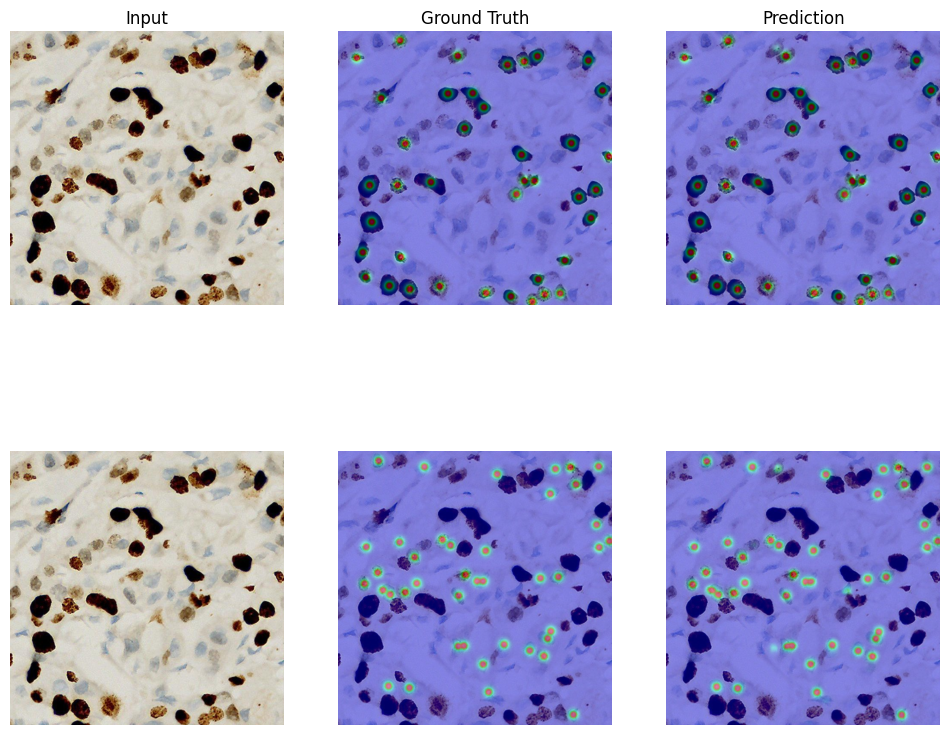

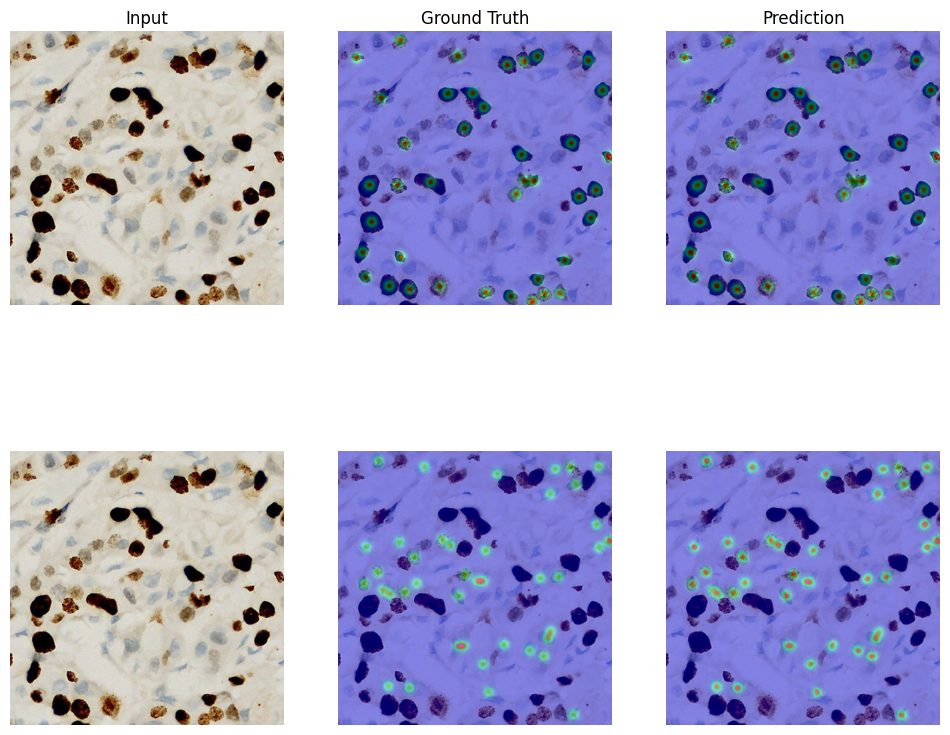

In [16]:
img, loc_heatmap, count_heatmap, pos_pts, neg_pts = train_dataset[1]
img = img.to(device)
loc_heatmap = loc_heatmap.to(device)
count_heatmap = count_heatmap.to(device)


pred_loc_hm, pred_den_hm, pred_count = model(img.unsqueeze(0))

alpha = 0.4
color_map = cv2.COLORMAP_RAINBOW
overlay_heatmap(img, torch.sigmoid(pred_loc_hm[0]), loc_heatmap, alpha=alpha, color_map=color_map)
overlay_heatmap(img, F.softplus(pred_den_hm[0]), count_heatmap, alpha=alpha, color_map=color_map)

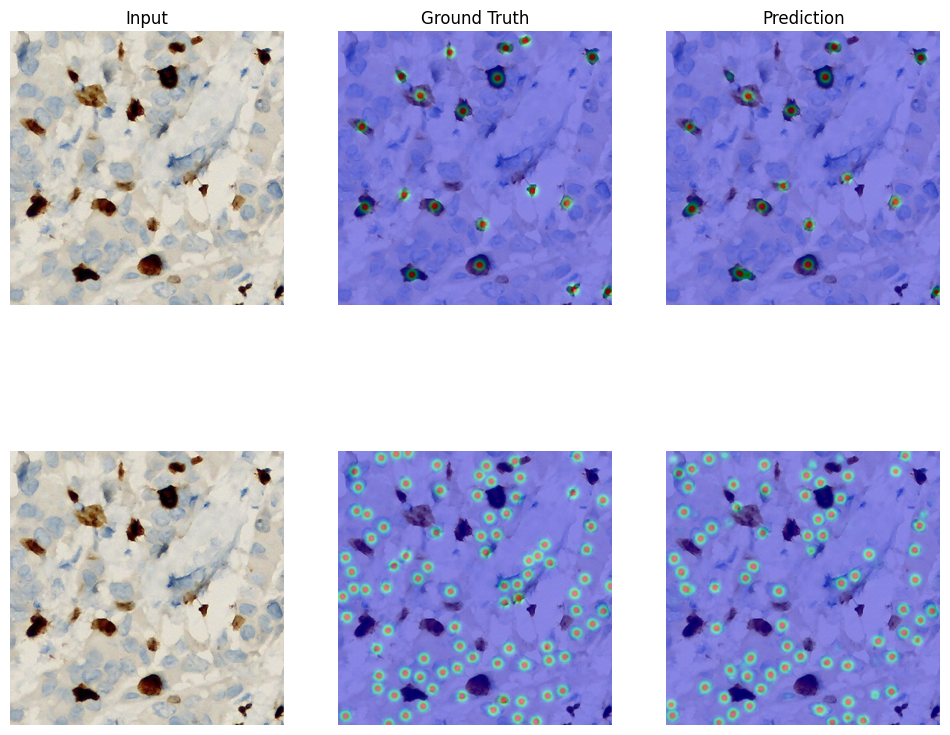

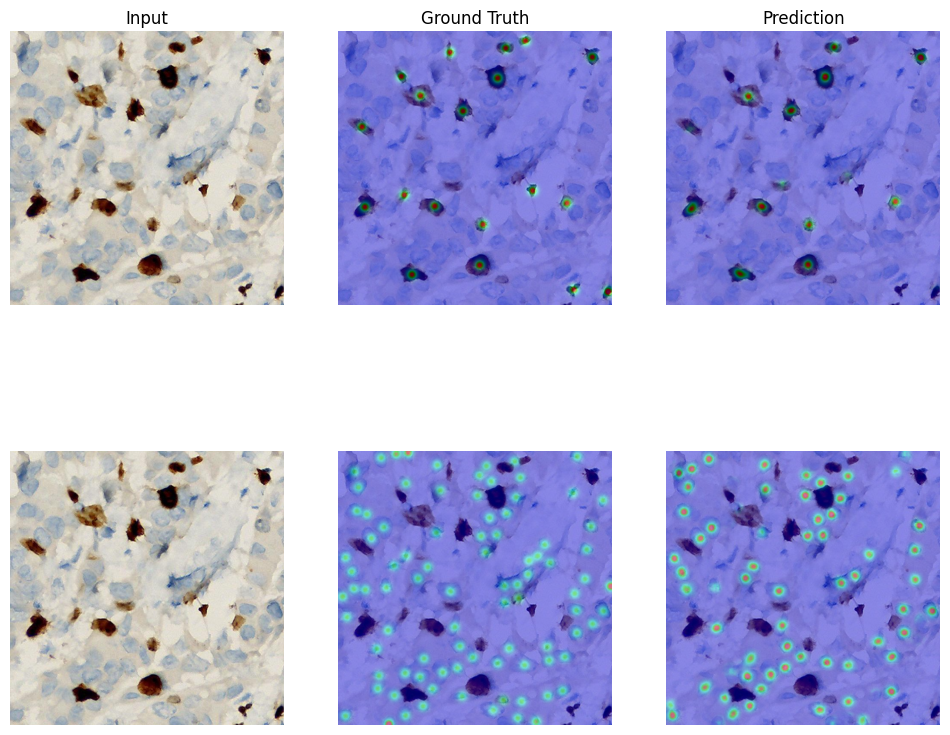

In [18]:
img, loc_heatmap, count_heatmap, pos_pts, neg_pts = test_dataset[1]
img = img.to(device)
loc_heatmap = loc_heatmap.to(device)
count_heatmap = count_heatmap.to(device)


pred_loc_hm, pred_den_hm, pred_count = model(img.unsqueeze(0))

alpha = 0.4
color_map = cv2.COLORMAP_RAINBOW
overlay_heatmap(img, torch.sigmoid(pred_loc_hm[0]), loc_heatmap, alpha=alpha, color_map=color_map)
overlay_heatmap(img, F.softplus(pred_den_hm[0]), count_heatmap, alpha=alpha, color_map=color_map)

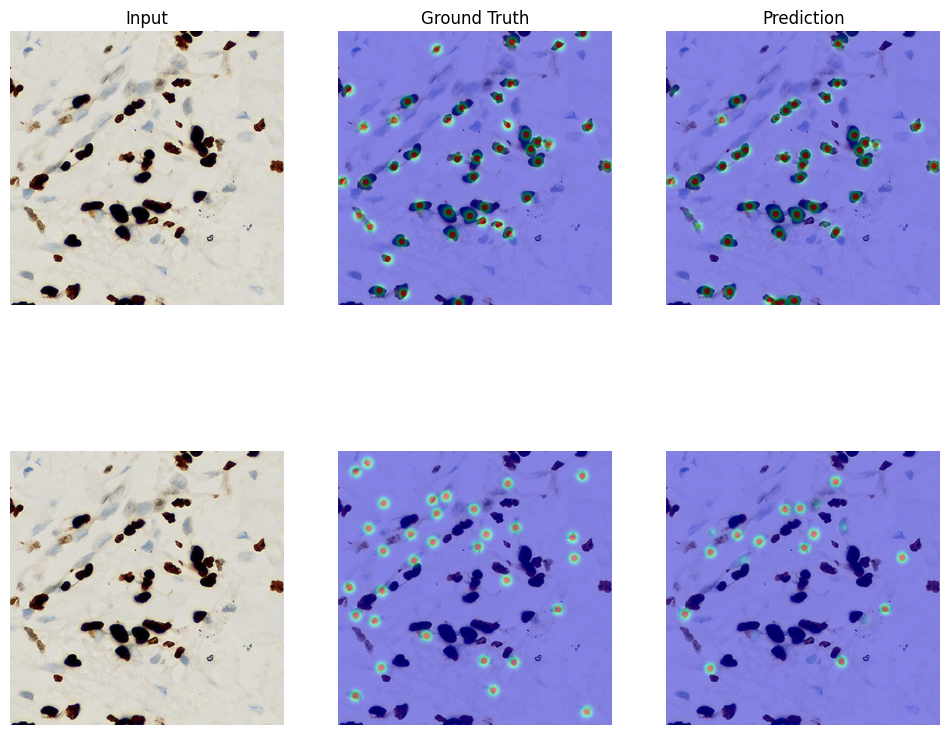

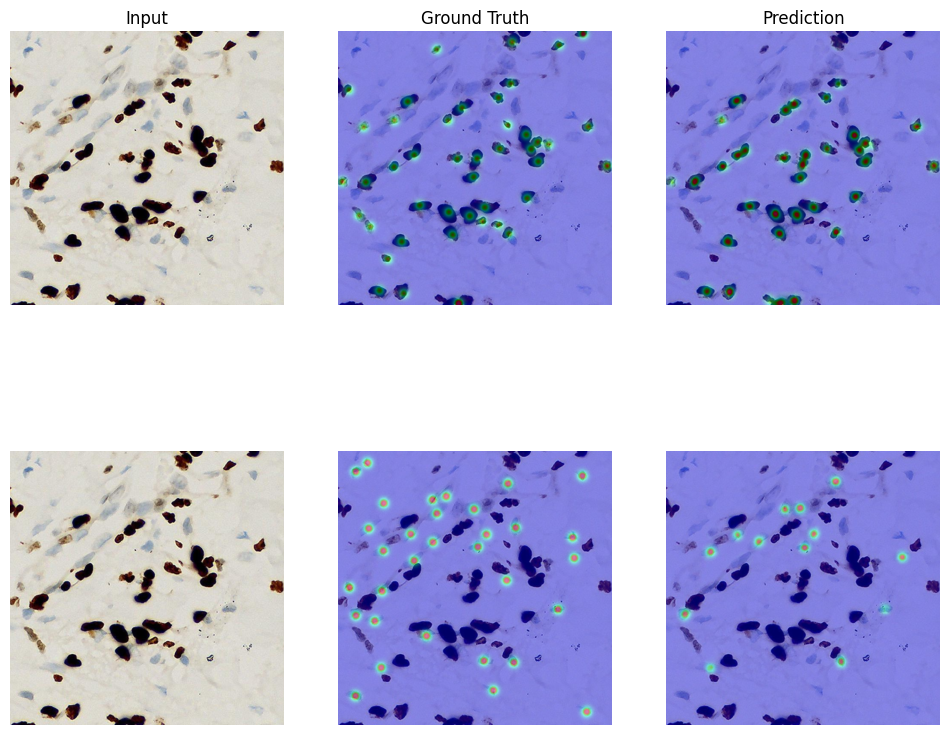

In [19]:
img, loc_heatmap, count_heatmap, pos_pts, neg_pts = val_dataset[1]
img = img.to(device)
loc_heatmap = loc_heatmap.to(device)
count_heatmap = count_heatmap.to(device)


pred_loc_hm, pred_den_hm, pred_count = model(img.unsqueeze(0))

alpha = 0.4
color_map = cv2.COLORMAP_RAINBOW
overlay_heatmap(img, torch.sigmoid(pred_loc_hm[0]), loc_heatmap, alpha=alpha, color_map=color_map)
overlay_heatmap(img, F.softplus(pred_den_hm[0]), count_heatmap, alpha=alpha, color_map=color_map)